In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load processed data
df = pd.read_csv("../data/processed_keystroke_data.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (190710, 14)

First 5 rows:


,hold_mean,hold_std,hold_min,hold_max,hold_median,hold_range,flight_mean,flight_std,flight_min,flight_max,flight_median,flight_range,num_keystrokes,target
0,103.140000,109.917607,63.0,761.0,76.5,698.0,254.224490,89.431599,111.0,542.0,236.0,431.0,50.0,0
1,97.914894,89.666007,60.0,543.0,75.0,483.0,248.869565,90.927972,112.0,501.0,238.5,389.0,47.0,0
2,99.234043,97.960525,62.0,587.0,76.0,525.0,239.847826,77.332418,119.0,501.0,229.0,382.0,47.0,0
3,93.633987,96.062599,60.0,953.0,76.0,893.0,251.421053,90.731641,108.0,701.0,237.0,593.0,153.0,0
4,89.000000,66.501279,60.0,605.0,76.0,545.0,242.915254,93.420462,99.0,716.0,229.0,617.0,119.0,0


In [3]:
# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (190710, 13)
Target shape: (190710,)


In [4]:
# Check class distribution

print(y.value_counts())
print("\nClass percentages:")
print(y.value_counts(normalize=True) * 100)

target
0    177145
1     13565
Name: count, dtype: int64

Class percentages:
target
0    92.887106
1     7.112894
Name: proportion, dtype: float64


In [5]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (152568, 13)
Testing data: (38142, 13)

Training target distribution:
target
0    141716
1     10852
Name: count, dtype: int64

Testing target distribution:
target
0    35429
1     2713
Name: count, dtype: int64


In [6]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [7]:
# Make predictions on test data

y_pred = rf_model.predict(X_test)

print("Predictions completed!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions completed!
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.9249908237638299
Precision: 0.2909604519774011
Recall   : 0.03796535200884629
F1-Score : 0.06716661232474731


[[35178   251]
 [ 2610   103]]


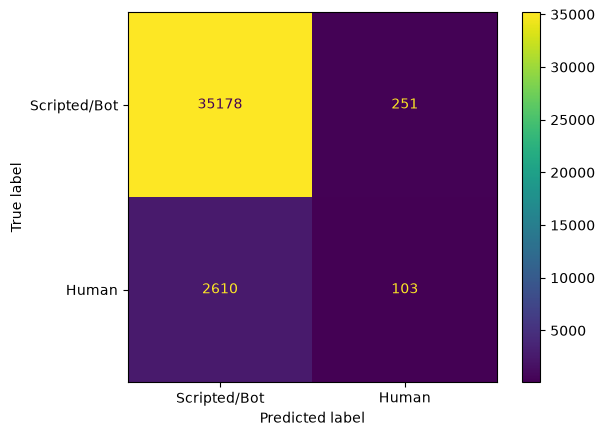

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Scripted/Bot", "Human"]
).plot()

plt.show()